# 00. Homework description

For this assignment, your task is to develop the [FastPitch](https://arxiv.org/abs/2006.06873) synthesis model, train it, and generate several audio samples.

The training and data processing code has already been provided for you. The training will be conducted on the LJspeech dataset.

The total score for the homework is **10 points**, distributed as follows:
- 1 point for visualizing the input data
- 8 points for writing the model code and running training
- 1 point for pitch and duration manipulations during inference

The homework submission **should include**:
- Completed notebook
- Attached WER and loss graphs from TensorBoard
- 1 audio file - the result of a regular model inference
- 4 additional audio files: you are encouraged to experiment with adjusting phoneme durations and pitch slightly and listen to the results.

# 01. Preparation steps

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 --upgrade

Looking in indexes: https://download.pytorch.org/whl/cu121


In [2]:
device = "cuda"
gpu_avaiable = "1"    # Run nvidia-smi to find free GPU

In [3]:
import os

path_to_sources = os.path.dirname(os.getcwd())

In [4]:
# If running in colab

# clone the repository:
# git clone https://github.com/yandexdataschool/speech_course.git
# !pip install -r speech_course/week_08_tts_am_vocoders/requirements.txt

### Dataset

We will work with [LJSpeech](https://keithito.com/LJ-Speech-Dataset/) -- a single-speaker dataset with 24 hours of speech.

The data we will use contains pre-computed [MFA-alignments](https://montreal-forced-aligner.readthedocs.io/en/latest/user_guide/workflows/alignment.html) alongside with the original wavs and texts. If you are interested in the process of extracting such alignments, please refer to this [tutorial](https://colab.research.google.com/gist/NTT123/12264d15afad861cb897f7a20a01762e/mfa-ljspeech.ipynb).

Download the dataset with precomputed alignments.

In [5]:
import requests
from urllib.parse import urlencode
from io import BytesIO
from zipfile import ZipFile

base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
public_key = 'https://disk.yandex.ru/d/PpgePfWcQTAbug'

# final_url = base_url + urlencode(dict(public_key=public_key))
# response = requests.get(final_url)
# download_url = response.json()['href']
# response = requests.get(download_url)

path_to_dataset = 'data/ljspeech'    # Choose any appropriate local path

# # If running in Colab:
# # path_to_dataset = '/content/ljspeech_aligned'

# zipfile = ZipFile(BytesIO(response.content))
# zipfile.extractall(path=path_to_dataset)

### Hi-Fi GAN checkpoint


Download a pretrained Hi-Fi GAN checkpoint (to generate audio from the predicted mel-spectrograms).

In [6]:
# !wget --content-disposition https://api.ngc.nvidia.com/v2/models/nvidia/dle/hifigan__pyt_ckpt_ds-ljs22khz/versions/21.08.0_amp/zip -O hifigan_ckpt.zip
# !unzip hifigan_ckpt.zip
# !rm hifigan_ckpt.zip

In [7]:
# In colab:
# !wget --content-disposition https://api.ngc.nvidia.com/v2/models/nvidia/dle/hifigan__pyt_ckpt_ds-ljs22khz/versions/21.08.0_amp/zip -O /content/hifigan_ckpt.zip
# !unzip /content/hifigan_ckpt.zip
# !rm /content/hifigan_ckpt.zip

In [8]:
path_to_hfg_ckpt = "hifigan_gen_checkpoint_6500.pt" 

### Imports

In [9]:
import sys
import os
import json
import dataclasses
import torch
import subprocess as sp
import matplotlib.pylab as plt
import soundfile as sf

from g2p_en import G2p
import IPython.display as Ipd

In [10]:
sys.path.append(path_to_sources)

# 02. See a data sample (1 point)

In [11]:
from sources.fastpitch.hparams import HParamsFastpitch
from sources.fastpitch.data import prepare_loaders

The mfa alignment provides phonemes and their durations, which we will need during training:

In [12]:
with open(os.path.join(path_to_dataset, 'mfa_aligned', 'LJ001-0001.json')) as f:
  utterance = json.load(f)

utterance

{'start': 0,
 'end': 9.655062,
 'tiers': {'words': {'type': 'interval',
   'entries': [[0.0, 0.69, 'printing'],
    [0.69, 0.82, '<eps>'],
    [0.82, 1.01, 'in'],
    [1.01, 1.15, 'the'],
    [1.15, 1.45, 'only'],
    [1.45, 1.97, 'sense'],
    [1.97, 2.14, 'with'],
    [2.14, 2.39, 'which'],
    [2.39, 2.54, 'we'],
    [2.54, 2.71, 'are'],
    [2.71, 2.89, 'at'],
    [2.89, 3.28, 'present'],
    [3.28, 4.0, 'concerned'],
    [4.0, 4.41, '<eps>'],
    [4.41, 5.01, 'differs'],
    [5.01, 5.04, '<eps>'],
    [5.04, 5.28, 'from'],
    [5.28, 5.65, 'most'],
    [5.65, 5.82, 'if'],
    [5.82, 6.1, 'not'],
    [6.1, 6.29, 'from'],
    [6.29, 6.63, 'all'],
    [6.63, 6.78, 'the'],
    [6.78, 7.09, 'arts'],
    [7.09, 7.22, 'and'],
    [7.22, 7.8, 'crafts'],
    [7.8, 8.45, 'represented'],
    [8.45, 8.66, 'in'],
    [8.66, 8.79, 'the'],
    [8.79, 9.6, 'exhibition'],
    [9.6, 9.655062, '<eps>']]},
  'phones': {'type': 'interval',
   'entries': [[0.0, 0.04, 'P'],
    [0.04, 0.07, 'R'],
    [0

Phoneme `sil` here denotes pause -- a period of silence between spoken phonemes. The phonemes are from [ARPA](https://en.wikipedia.org/wiki/ARPABET) alphabet.

In [13]:
hparams = HParamsFastpitch()
train_loader, val_loader = prepare_loaders(path_to_dataset, hparams)

In [14]:
train_iter = iter(train_loader)
batch = next(train_iter)

In [15]:
list(dataclasses.asdict(batch).keys())

['texts',
 'text_lengths',
 'mels',
 'mel_lengths',
 'pitches',
 'durations',
 'paces']

In [16]:
batch.mels.shape

torch.Size([10, 80, 856])

In [17]:
batch.pitches.shape

torch.Size([10, 103])

In [18]:
batch.durations.shape

torch.Size([10, 103])

## Task

**(0.5 points)** Draw a combined image showing both the mel-spectrogram and pitch for a sample from the batch. Use durations to ensure proper alignment of their shapes in the image.  
**(0.5 points)** Include phoneme labels near the time axis on the image from the previous step. (like in Figure 3 in the [paper](https://arxiv.org/pdf/2006.06873.pdf)). You may find the code from the seminar helpful.

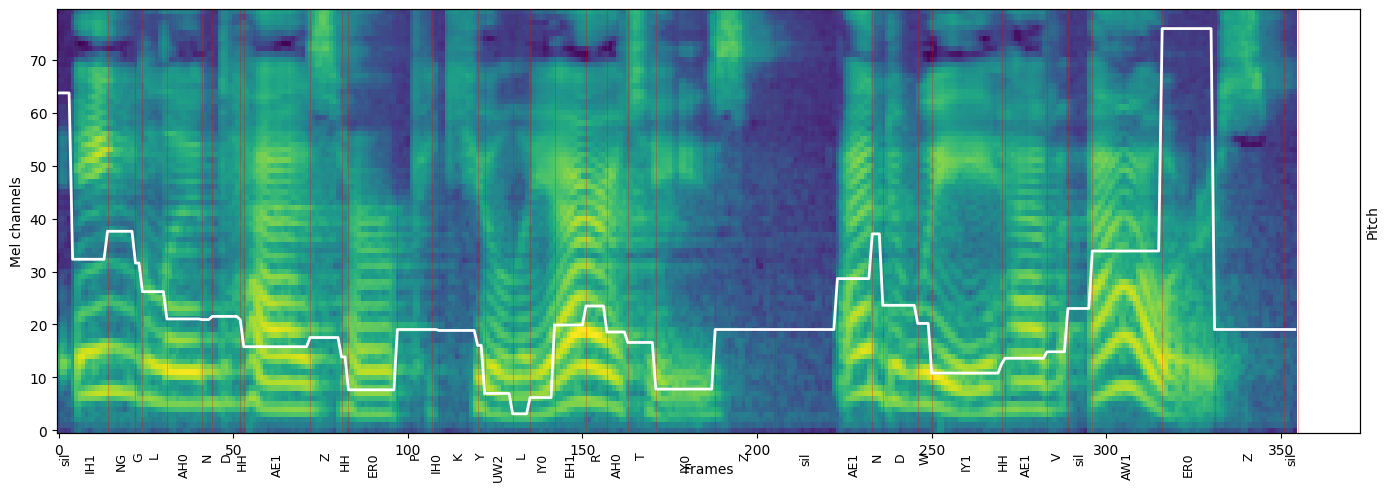

In [19]:
import numpy as np
from sources.fastpitch.data import SymbolsSet

symbols_set = SymbolsSet()

sample_idx = 0
text_len = batch.text_lengths[sample_idx].item()
mel_len = batch.mel_lengths[sample_idx].item()

mel = batch.mels[sample_idx, :, :mel_len].cpu().numpy()
phone_durations = batch.durations[sample_idx, :text_len].cpu().numpy()
phone_pitch = batch.pitches[sample_idx, :text_len].cpu().numpy()
symbols = symbols_set.decode(batch.texts[sample_idx, :text_len].cpu().tolist())

frame_pitch = np.repeat(phone_pitch, phone_durations)

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(mel, aspect='auto', origin='lower', interpolation='none')
ax.set_xlabel('Frames')
ax.set_ylabel('Mel channels')

ax2 = ax.twinx()
ax2.plot(frame_pitch, color='white', linewidth=2)
ax2.set_yticks([])
ax2.set_ylabel('Pitch')

bounds = np.concatenate([[0], np.cumsum(phone_durations)])
for i, sym in enumerate(symbols):
    center = (bounds[i] + bounds[i + 1]) / 2
    ax.text(center, -4, sym, ha='center', va='top', fontsize=9, rotation=90)
for b in bounds:
    ax.axvline(b, color='red', alpha=0.3, linewidth=0.7)

plt.tight_layout()
plt.show()

# 03. Implement FastPitch model (9 points)

In [20]:
audio, sr = sf.read('prediction_example.wav')
Ipd.display(Ipd.Audio(audio, rate=sr))

In [21]:
# !mkdir -p new/speech_course/week_08_tts_am_vocoders/sources/fastpitch/

In [22]:
%%writefile new/speech_course/week_08_tts_am_vocoders/sources/fastpitch/model.py

import torch
from torch import nn as nn

from sources.fastpitch.common.layers import TemporalPredictor
from sources.fastpitch.common.utils import DeviceGetterMixin
from sources.fastpitch.common.utils import regulate_len
from sources.fastpitch.data import FastPitchBatch, SymbolsSet
from sources.fastpitch.hparams import HParamsFastpitch
from sources.fastpitch.common.transformer import FFTransformer


class FastPitch(nn.Module, DeviceGetterMixin):
    def __init__(self, hparams: HParamsFastpitch):
        super().__init__()
        self.hparams = hparams
        n_symbols = len(SymbolsSet().symbols_to_id)

        self.symbol_emb = nn.Embedding(n_symbols, hparams.symbols_embedding_dim)

        self.encoder = FFTransformer(
            n_layer=hparams.in_fft_n_layers,
            n_head=hparams.in_fft_n_heads,
            d_model=hparams.symbols_embedding_dim,
            d_head=hparams.in_fft_d_head,
            d_inner=4 * hparams.symbols_embedding_dim,
            kernel_size=hparams.in_fft_conv1d_kernel_size,
            dropout=hparams.p_in_fft_dropout,
            dropatt=hparams.p_in_fft_dropatt,
            dropemb=hparams.p_in_fft_dropemb
        )

        self.duration_predictor = TemporalPredictor(
            input_size=hparams.symbols_embedding_dim,
            filter_size=hparams.dur_predictor_filter_size,
            kernel_size=hparams.dur_predictor_kernel_size,
            dropout=hparams.p_dur_predictor_dropout,
            n_layers=hparams.dur_predictor_n_layers
        )

        self.pitch_predictor = TemporalPredictor(
            input_size=hparams.symbols_embedding_dim,
            filter_size=hparams.pitch_predictor_filter_size,
            kernel_size=hparams.pitch_predictor_kernel_size,
            dropout=hparams.p_pitch_predictor_dropout,
            n_layers=hparams.pitch_predictor_n_layers
        )

        self.pitch_emb = nn.Conv1d(1, hparams.symbols_embedding_dim, kernel_size=3, padding=1)

        self.decoder = FFTransformer(
            n_layer=hparams.out_fft_n_layers,
            n_head=hparams.out_fft_n_heads,
            d_model=hparams.symbols_embedding_dim,
            d_head=hparams.out_fft_d_head,
            d_inner=4 * hparams.symbols_embedding_dim,
            kernel_size=hparams.out_fft_conv1d_kernel_size,
            dropout=hparams.p_out_fft_dropout,
            dropatt=hparams.p_out_fft_dropatt,
            dropemb=hparams.p_out_fft_dropemb
        )

        self.proj = nn.Linear(hparams.symbols_embedding_dim, hparams.n_mel_channels, bias=True)

    def get_encoder_out(self, batch: FastPitchBatch):
        '''
        Return: 
        enc_out: 
            Output of the first series of FFT blocks (before adding pitch embedding)
            shape: (batch, len(text), symbols_embedding_dim)
        enc_mask:
            Boolean padding mask for the input text sequences
            shape: (batch, len(text), 1)
        '''
        text_emb = self.symbol_emb(batch.texts)
        enc_out, enc_mask = self.encoder(text_emb, batch.text_lengths)
        return enc_out, enc_mask

    def forward(self, batch: FastPitchBatch, use_gt_durations=True, use_gt_pitch=True, max_duration=75):
        '''
        Flags `use_gt_durations` and `use_gt_pitch` should be both True during training and either True or False during inference.

        Use the function `regulate_len` to duplicate phonemes according to durations before passing them to the decoder.
        
        Return:
        mel_out:
            Predicted mel-spectrograms
            shape: (batch, time, mel_bins)
        mel_lens:
            Number of time frames in each of the predicted spectrograms
            shape: (batch,)
        log_dur_pred:
            The predicted log-durations for each phoneme (the output of the duration predictor).
            shape: (batch, len(text))
        dur_pred:
            The exponent of the predicted log-durations for each phoneme. Clamped to the range (0, max_duration) for numeric stability
            shape: (batch, len(text))
        pitch_pred:
            The predicted pitch for each phoneme
            shape: (batch, len(text))
        '''
        enc_out, enc_mask = self.get_encoder_out(batch)

        log_dur_pred = self.duration_predictor(enc_out, enc_mask)
        dur_pred = torch.clamp(torch.exp(log_dur_pred) - 1, 0, max_duration)

        pitch_pred = self.pitch_predictor(enc_out, enc_mask)
        pitch_used = batch.pitches if use_gt_pitch else pitch_pred
        pitch_emb = self.pitch_emb(pitch_used.unsqueeze(1)).transpose(1, 2)
        enc_out = enc_out + pitch_emb

        dur_used = batch.durations if use_gt_durations else dur_pred
        len_regulated, dec_lens, _ = regulate_len(dur_used, enc_out)

        dec_out, _ = self.decoder(len_regulated, dec_lens)
        mel_out = self.proj(dec_out)

        return mel_out, dec_lens, dur_pred, log_dur_pred, pitch_pred

    @torch.no_grad()
    def infer(self, batch: FastPitchBatch, max_duration=75):
        enc_out, dur_pred, pitch_pred = self.infer_encoder(batch, max_duration=max_duration)
        mel_out, mel_lens = self.infer_decoder(enc_out, dur_pred)
        return mel_out, mel_lens, dur_pred, pitch_pred

    def infer_encoder(self, batch: FastPitchBatch, max_duration=75):
        enc_out, enc_mask = self.get_encoder_out(batch)

        log_dur_pred = self.duration_predictor(enc_out, enc_mask)
        dur_pred = torch.clamp(torch.exp(log_dur_pred) - 1, 0, max_duration)

        pitch_pred = self.pitch_predictor(enc_out, enc_mask)
        pitch_emb = self.pitch_emb(pitch_pred.unsqueeze(1)).transpose(1, 2)
        enc_out = enc_out + pitch_emb

        return enc_out, dur_pred, pitch_pred

    def infer_decoder(self, enc_out, dur_pred):
        len_regulated, dec_lens, _ = regulate_len(dur_pred, enc_out)
        dec_out, _ = self.decoder(len_regulated, dec_lens)
        mel_out = self.proj(dec_out)
        return mel_out, dec_lens


Overwriting new/speech_course/week_08_tts_am_vocoders/sources/fastpitch/model.py


In [23]:
 # Allows reloading code import without kernel restart
%load_ext autoreload
%autoreload 2

In [24]:
from sources.fastpitch.model import FastPitch

In [25]:
fp = FastPitch(hparams)

In [26]:
enc_out, enc_mask = fp.get_encoder_out(batch)

In [27]:
assert enc_out.shape == torch.Size([hparams.batch_size, batch.texts.shape[1], hparams.symbols_embedding_dim])
assert enc_mask.shape == torch.Size([hparams.batch_size, batch.texts.shape[1], 1])

In [28]:
mel_out, mel_lens, dur_pred, log_dur_pred, pitch_pred = fp.forward(batch)

In [29]:
assert mel_out.shape == batch.mels.transpose(2, 1).shape
assert mel_lens.shape == batch.mel_lengths.shape
assert dur_pred.shape == batch.texts.shape
assert dur_pred.shape == log_dur_pred.shape
assert pitch_pred.shape == batch.texts.shape

### Run training

In [30]:
logs_dir = "logs"     # Choose any paths
ckpt_dir = "checkpoints"

In [31]:
os.makedirs(logs_dir, exist_ok=True)
os.makedirs(ckpt_dir, exist_ok=True)

In [32]:
!pip install "matplotlib<3.9"
!pip install "transformers<4.40.0"

In [33]:
sp.check_call(
    ' '.join([
        f'PYTHONPATH={path_to_sources} CUDA_VISIBLE_DEVICES={gpu_avaiable}',
        f'python3 -m sources.fastpitch.train_fastpitch',
        f'--logs {logs_dir}',
        f'--ckptdir {ckpt_dir}',
        f'--dataset {path_to_dataset}',
        f'--hfg {path_to_hfg_ckpt}'
    ]), shell=True
)

/home/jovyan/work/new/speech_course/week_08_tts_am_vocoders/sources/fastpitch/common/checkpointer.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  last_ckpt = torch.load

HiFi-GAN: Removing weight norm.


0

In [34]:
# If running in colab:

# %load_ext tensorboard
# %tensorboard --logdir logs

In [35]:
# If running in colab:

# %%shell

# mkdir logs checkpoints

# PYTHONPATH=speech_course python3 -m week_07_tts_am.fastpitch.train_fastpitch  \
# --logs logs \
# --ckptdir checkpoints \
# --dataset /content/ljspeech_aligned \
# --hfg /content/hifigan_gen_checkpoint_6500.pt

### Infer model on an example

Execute the code provided below. Then, append the generated audio to the homework results.
- if attaching an archive, use name: `prediction.wav`

In [36]:
from sources.fastpitch.common.checkpointer import Checkpointer
from sources.fastpitch.model import FastPitch
from sources.fastpitch.data import FastPitchBatch, SymbolsSet
from sources.hifigan.model import load_model as load_hfg_model

In [37]:
def get_symbol_ids(text):
    g2p = G2p()
    phonemes = g2p(text)

    symbols_set = SymbolsSet()
    
    symbols = []
    for ph in phonemes:
        if ph in symbols_set.symbols_to_id:
            symbols.append(ph)
        elif ph == ' ':
            continue
        else:
            symbols.append("sil")
    
    symbols_ids = torch.LongTensor(symbols_set.encode(symbols))
    text_length = torch.LongTensor([symbols_ids.shape[0]])

    return symbols_ids, text_length

In [38]:
checkpointer = Checkpointer(ckpt_dir)

In [39]:
hfg = load_hfg_model(path_to_hfg_ckpt)
hfg = hfg.to(device).eval()

/home/jovyan/work/new/speech_course/week_08_tts_am_vocoders/sources/hifigan/model.py:461: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_data = torch.load(checkpoint_pat

HiFi-GAN: Removing weight norm.


In [40]:
ckpt_dict = checkpointer.load_last_checkpoint()
hparams = HParamsFastpitch.create(ckpt_dict['hparams'])
fp = FastPitch(hparams)
fp.load_state_dict(ckpt_dict['state_dict'])
fp = fp.to(device)

/home/jovyan/work/new/speech_course/week_08_tts_am_vocoders/sources/fastpitch/common/checkpointer.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  last_ckpt = torch.load

In [41]:
text = "Freestyler, rock the microphone, straight from the top of my dome. Freestyler, rock the microphone, carry on with the freestyler."

In [42]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

# g2p_en often requires the CMU pronouncing dictionary as well, 
# so it's a good idea to download it now to prevent the next potential error:
nltk.download('cmudict')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package cmudict to /home/jovyan/nltk_data...
[nltk_data]   Package cmudict is already up-to-date!


True

In [43]:
symbols_ids, lengths = get_symbol_ids(text)

batch = FastPitchBatch(
    texts=symbols_ids.unsqueeze(0),
    text_lengths=lengths
).to(device)

In [44]:
with torch.no_grad():
    mels, mel_lens, *_ = fp.infer(batch)
    mels = mels.permute(0, 2, 1)
    audio = hfg(mels)

Ipd.display(Ipd.Audio(audio.squeeze().cpu().detach().numpy(), rate=22050))

### Pitch & duration manipulations (1 point)

- **(0.5 points)** Try increasing and decreasing the prediction speed by a factor of 2, draw spectrograms for each case
    - if attaching an archive, use names:  `prediction_half_dur.wav`,  `prediction_double_dur.wav`
- **(0.5 points)** Try shifting prediction pitch 50 Hz up and down, draw spectrograms for each case
    - if attaching an archive, use names:  `prediction_50hz_up.wav`,  `prediction_50hz_down.wav`

Аttach resulting audio files to the homework report. 

In [45]:
def scale_durations(durations: torch.Tensor, scale_factor: float):
    return torch.round(durations * scale_factor).long()


def shift_pitch(pitch: torch.Tensor, shift: float):
    scale = 62.51305    # Mean and variance of pitch in LJSpeech used for target pitch normalization
    mean = 215.42230
    return pitch + shift / scale

In [46]:
_, dur_pred, pitch_pred = fp.infer_encoder(batch)

In [47]:
batch = FastPitchBatch(
    texts=symbols_ids.unsqueeze(0),
    text_lengths=lengths,
    pitches=shift_pitch(pitch_pred, shift=0),
    durations=scale_durations(dur_pred, scale_factor=2)
).to(device)

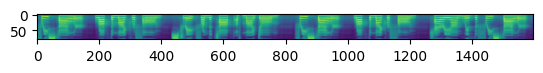

In [48]:
with torch.no_grad():
    mels, mel_lens, *_ = fp(batch, use_gt_durations=True, use_gt_pitch=True)
    mels = mels.permute(0, 2, 1)
    audio = hfg(mels)

Ipd.display(Ipd.Audio(audio.squeeze().cpu().detach().numpy(), rate=22050))
plt.imshow(mels.squeeze().cpu().detach().numpy())
plt.show()